# IncentiveScope — GMX STIP historical research
## tl;dr
The fixed cohort contains **22,145 protocol accounts**. **954 accounts (4.31%)** opened or increased a position during post days 24–30; **2,997 (13.53%)** did so anywhere in the first 30 days. Two-day participation in the late window is **473 (2.14%)**.

This is descriptive account-level research. It does not identify people, estimate causal incentive lift, or establish an acquisition cost. Default execution displays the committed result snapshot; full event recomputation is an explicit option below.

## Context & Methods
**Question:** Did protocol accounts that traded during the rebate earning window continue opening or increasing positions after earning ended?

- Chain: Arbitrum, GMX V2 perpetuals.
- Earning interval: **[2023-11-15 00:00:01, 2024-03-27 00:00:00) UTC**.
- R30 interval: **[2024-04-19, 2024-04-26) UTC**, post days 24–30.
- Cohort eligibility: at least one successful positive-size increase/open execution during the earning interval. Every eligible account remains in the denominator, including nonreturners.
- R30 counts a qualifying execution in the late interval. Cumulative30 uses the whole first 30-day interval. Sustained30 requires two distinct UTC activity dates in the late interval.
- Liquidation, collateral-only changes and cancelled orders do not qualify as new opening/increase participation. The source lacks the secondary ADL marker; some MarketDecrease executions may be forced ADL. Therefore the real-data voluntary30 metric is withheld. Opening-or-decrease candidates are a separately labelled broader count.

### Key Assumptions
The extraction starts on September 20, 2023, rather than deployment: “first observed” is not “new user.” GMX's trading competition overlaps the last two earning weeks, and Binance Wallet tasks overlap the first two post weeks. Their effects are not identified separately. Reward allocations are not payment receipts; receiver overrides prevent reliable attribution of every allocation to the original trading account.

Method and source evidence: [earning boundaries](../docs/boundary-evidence.md), [event validation](../docs/event-validation.md), [campaign definitions](../docs/campaign.md), and the shared [metric SQL](../src/incentivescope/metrics.sql).

### Set execution mode
Install the repository's notebook extras once: <code>python -m pip install -e ".[notebook]"</code>.

Default: load <code>reports/gmx-stip/results.json</code> and regenerate figures from that result. This mode neither fetches events nor reruns the event SQL. Set environment variable <code>INCENTIVESCOPE_RERUN_RAW=1</code> to opt into full recomputation from the local normalized CSV and manifest; the exact snapshot is available in the project's [v0.2.0 release](https://github.com/ho2006/IncentiveScope/releases/tag/v0.2.0). Full recomputation uses the package's analyzer and SQL, writes into a temporary directory, and checks agreement with the committed metrics. It never replaces the committed report.

In [1]:
import json
import os
from pathlib import Path
from tempfile import TemporaryDirectory
from IPython.display import HTML, SVG, display
from incentivescope.analyze import analyze
from incentivescope.report import figures, metric

root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = root.parent
assert (root / "pyproject.toml").exists(), "Run from the repository or notebooks directory."
config = json.loads((root / "configs/gmx-stip.json").read_text(encoding="utf-8"))
snapshot = json.loads((root / "reports/gmx-stip/results.json").read_text(encoding="utf-8"))
rerun_from_raw = os.environ.get("INCENTIVESCOPE_RERUN_RAW") == "1"
results = snapshot
print("Mode:", "full normalized-event recomputation" if rerun_from_raw else "committed snapshot display")


Mode: committed snapshot display


## Data
The snapshot covers **[2023-09-20, 2024-05-29) UTC** and records 907,107 normalized execution events. The complete declaration refers to the requested extraction window, rather than all protocol history or an independent chain replay.

The published SHA-256 identifies the normalized CSV. In default snapshot mode it is provenance metadata; the notebook does not possess or verify the full CSV. The opt-in analyzer checks file checksum, declared coverage, row count, event uniqueness, schema, account attribution and timestamps before running metrics.

In [2]:
assert results["dataset"]["is_synthetic"] is False
assert results["dataset"]["boundary_status"] == "verified"
assert (results["campaign"]["start"], results["campaign"]["end"]) == (config["start"], config["end"])
print(json.dumps({
    "source": results["dataset"]["source_url"],
    "coverage_start": results["dataset"]["coverage_start"],
    "coverage_end": results["dataset"]["coverage_end"],
    "normalized_csv_sha256": results["dataset"]["sha256"],
    "normalized_events": results["quality"]["row_count"],
    "qualifying_increases": results["quality"].get("qualifying_increases"),
    "order_created_coverage": results["quality"]["order_created_coverage"],
    "position_fee_coverage": results["quality"].get("position_fee_coverage"),
}, indent=2))


{
  "source": "https://gmx.squids.live/gmx-synthetics-arbitrum:prod/api/graphql",
  "coverage_start": "2023-09-20T00:00:00Z",
  "coverage_end": "2024-05-29T00:00:00Z",
  "normalized_csv_sha256": "76e4992debf0bf2e60328221c94c840aa97c2c7545550085bcd3e83d09fe61a3",
  "normalized_events": 907107,
  "qualifying_increases": 480267,
  "order_created_coverage": 1.0,
  "position_fee_coverage": 1.0
}


In [3]:
if rerun_from_raw:
    raw = root / "data/raw/gmx-stip"
    if not (raw / "trades.csv").exists() or not (raw / "manifest.json").exists():
        raise FileNotFoundError("Download and decompress the v0.2.0 snapshot into data/raw/gmx-stip first.")
    with TemporaryDirectory(prefix="incentivescope-gmx-notebook-") as directory:
        recomputed = analyze(config, raw / "trades.csv", raw / "manifest.json", Path(directory))
    assert recomputed["dataset"]["sha256"] == snapshot["dataset"]["sha256"], "Different source snapshot."
    for field in ("summary", "cohorts", "weekly", "heatmap", "segments", "robustness", "activity"):
        assert recomputed[field] == snapshot[field], f"Recomputed {field} differs from committed results."
    results = recomputed
    print("Full normalized-event recomputation matches every committed metric group.")
else:
    print("Snapshot mode: source-event SQL recomputation was not requested.")


Snapshot mode: source-event SQL recomputation was not requested.


### Check metric consistency
These checks reconcile the displayed metric groups. They check a single result artifact and are not independent confirmation of upstream completeness.

In [4]:
summary = results["summary"]
assert summary["cohort_size"] == 22145
assert summary["r30"]["n"] == 954
assert summary["cumulative30"]["n"] == 2997
assert summary["sustained30"]["n"] == 473
assert sum(row["size"] for row in results["cohorts"]) == summary["cohort_size"]
assert sum(row["r30_n"] for row in results["cohorts"]) == summary["r30"]["n"]
for name in ("r30", "cumulative30", "sustained30", "voluntary30", "open_or_decrease30", "strict_r30", "r60"):
    value = summary[name]
    if value is not None:
        assert 0 <= value["n"] <= value["N"] == summary["cohort_size"]
        assert value["rate"] == value["n"] / value["N"]
assert summary["sustained30"]["n"] <= summary["r30"]["n"] <= summary["cumulative30"]["n"]
print("Fixed denominators, cohort sums and nested activity definitions reconcile.")

assert summary["voluntary30"] is None, "Voluntary attribution requires the absent ADL marker."

Fixed denominators, cohort sums and nested activity definitions reconcile.


## Results
### Return definitions answer different questions
The late-window R30 rate is lower than the cumulative 30-day return rate because the windows differ. The gap does not by itself identify why accounts stopped trading.

Definition,Qualifying / fixed cohort
r30,"4.3% (954/22,145 addresses)"
cumulative30,"13.5% (2,997/22,145 addresses)"
sustained30,"2.1% (473/22,145 addresses)"
voluntary30,N/A — unavailable
open_or_decrease30,"5.0% (1,101/22,145 addresses)"
strict_r30,"4.3% (954/22,145 addresses)"
r60,"5.1% (1,126/22,145 addresses)"


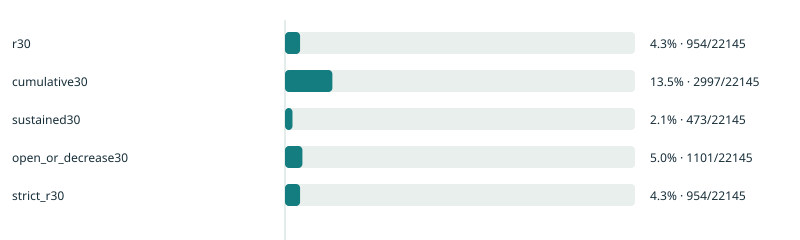

In [5]:
rows = "".join(
    f"<tr><td>{name}</td><td>{metric(summary[name])}</td></tr>"
    for name in ("r30", "cumulative30", "sustained30", "voluntary30", "open_or_decrease30", "strict_r30", "r60")
)
display(HTML("<table><thead><tr><th>Definition</th><th>Qualifying / fixed cohort</th></tr></thead><tbody>" + rows + "</tbody></table>"))
assets = figures(results)
display(SVG(assets["robustness"]))


R30 and strict new-order R30 both count 954 accounts. In this extract, the qualifying late-window increases were also submitted after earning ended. This equality applies to this source snapshot; it does not make the stricter definition redundant for other campaigns.

R60 counts 1,126 accounts (5.08%) in post days 54–60. It is a separate late-window observation, rather than a cumulative 60-day rate.

### Follow-up and entry-week cohorts
Weekly return bars retain all 22,145 accounts as their denominator. The heatmap uses each entry week's fixed cohort; its cells show numerator/denominator counts, allowing the final small cohort to be read without comparing raw counts as if populations were equal.

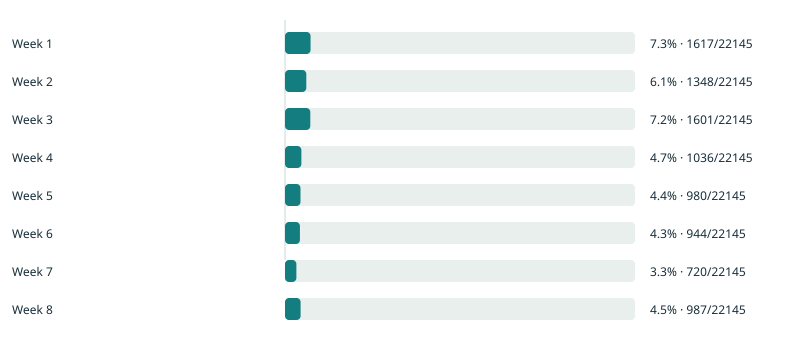

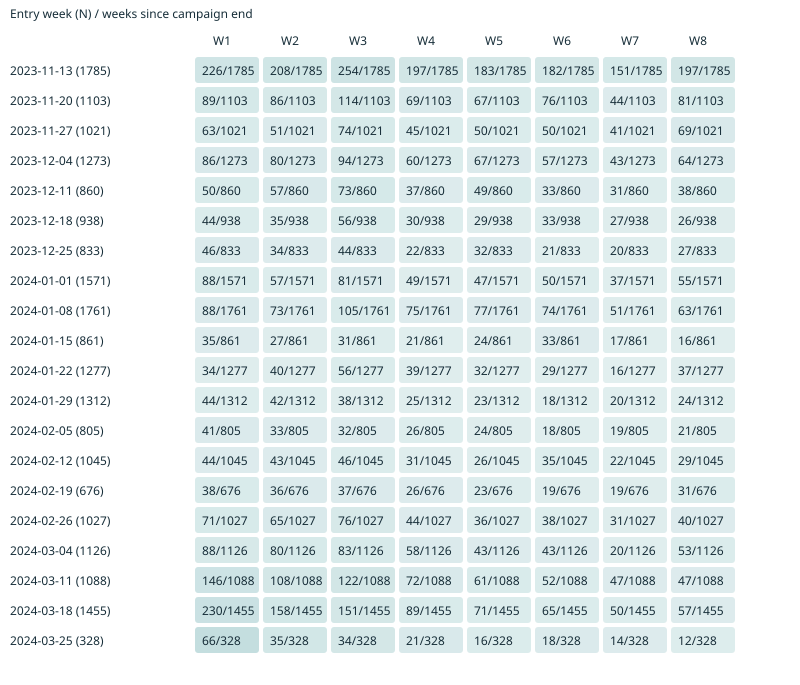

In [6]:
display(SVG(assets["weekly"]))
display(SVG(assets["heatmap"]))


### Observed history and concentration
History groups use activity before the campaign within the available extraction window. They do not establish new wallet creation or new protocol adoption.

The top 1% sensitivity ranks accounts on volume observed before earning ended, avoiding selection on later returns. It removes 222 accounts with a ceiling rule.

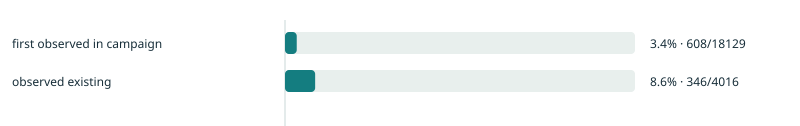

All addresses: 954/22,145 = 4.31%
Excluding top 1% (ceil): 904/21,923 = 4.12%


In [7]:
display(SVG(assets["history"]))
for segment in results["segments"]:
    print(f'{segment["label"]}: {segment["r30_n"]:,}/{segment["size"]:,} = {segment["r30_rate"]:.2%}')


Excluding the top 1% produces 904/21,923 = 4.12% R30, compared with 4.31% for all accounts. The main late-window result remains low under this pre-specified volume sensitivity. This does not identify bots or Sybil behavior.

### Equal-length activity and fees
The mature subset contains accounts first observed at least 30 days before the last earning midnight. Its pre and post intervals each have 30 full days, and inactive accounts remain in the denominator. Net position fees are **gross position fee minus trader discount**, valued with the token-adjusted collateral minimum price. They exclude external rebates, borrowing, funding, UI fees and gas; they are not protocol revenue.

Fixed mature cohort: 17,390 accounts
pre: 15,789 active account-days; activity rate 3.03%; net position fees USD 2,048,389.76
post: 8,825 active account-days; activity rate 1.69%; net position fees USD 690,673.21
Post/pre activity ratio: 0.559
Post/pre net-position-fee ratio: 0.337


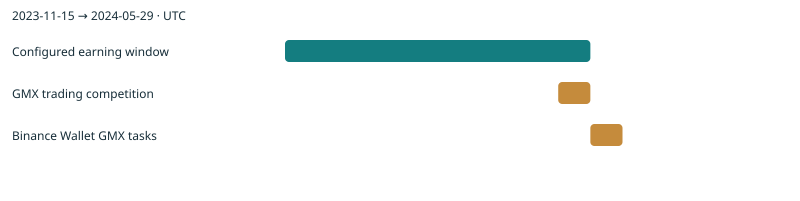

In [8]:
activity = results["activity"]
print("Fixed mature cohort:", f'{activity["eligibleN"]:,}', "accounts")
for window in ("pre", "post"):
    value = activity[window]
    print(f'{window}: {value["active_address_days"]:,} active account-days; '
          f'activity rate {value["activity_rate"]:.2%}; net position fees USD {value["position_fee_usd"]:,.2f}')
print(f'Post/pre activity ratio: {activity["activity_ratio"]:.3f}')
print(f'Post/pre net-position-fee ratio: {activity["fee_ratio"]:.3f}')
display(SVG(assets["timeline"]))


## Takeaways
- Late-window opening/increase participation is 4.31% of the campaign's fixed account cohort, compared with 13.53% cumulative 30-day return.
- The mature subset's account-day activity ratio is 0.559 and its net-position-fee ratio is 0.337, using equal 30-day windows. These are observed declines with overlapping programs and market conditions, rather than estimated incentive effects.
- Keep causal ROI and per-retained-account reward cost unavailable. Reward receiver overrides, unpublished pre-threshold statistics, and unverified payments do not support that attribution.

For the complete research narrative and source ledger, read the [English report](../reports/gmx-stip/research.md). This notebook preserves the same metric definitions and deterministic figures while making its execution mode explicit.